# DeepUDF for Peptides - Minimal Implementation
Using **Unsigned** Distance Function instead of Signed Distance Function

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from pathlib import Path
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from synthetic_peptides_dataset import SyntheticPeptidesDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
def compute_udf_samples(surface_points, n_samples=4096):
    tree = cKDTree(surface_points)
    near_idx = np.random.choice(len(surface_points), int(n_samples*0.3), replace=True)
    near_points = surface_points[near_idx] + np.random.normal(0, 0.03, (len(near_idx), 3))
    bbox_min, bbox_max = surface_points.min(0) - 0.7, surface_points.max(0) + 0.7
    rand_points = np.random.uniform(bbox_min, bbox_max, (n_samples - len(near_idx), 3))
    sample_points = np.vstack([near_points, rand_points])
    distances, _ = tree.query(sample_points)
    return sample_points, distances


class UDFDataset(Dataset):
    def __init__(self, peptide_dataset, n_samples=4096):
        self.peptide_dataset = peptide_dataset
        self.n_samples = n_samples

    def __len__(self):
        return len(self.peptide_dataset)

    def __getitem__(self, idx):
        surface = self.peptide_dataset[idx]["points"].numpy()
        coords, udf = compute_udf_samples(surface, self.n_samples)
        return torch.tensor(coords, dtype=torch.float32), torch.tensor(udf, dtype=torch.float32), idx

In [3]:
print("🎨 Visualizing UDF samples...")

try:
    test_data = SyntheticPeptidesDataset('./data/synthetic_peptides_split/train', num_files=1, structure_types=['nanotubes'])
except:
    test_data = SyntheticPeptidesDataset('./data/synthetic_peptides', num_files=1)

surface_np = test_data[0]["points"].numpy()
sample_coords, sample_udf = compute_udf_samples(surface_np, n_samples=10000)

very_close_mask = sample_udf < 0.02
close_mask = (sample_udf >= 0.02) & (sample_udf < 0.1)
far_mask = sample_udf >= 0.1

print(f"Very close: {np.sum(very_close_mask)} ({np.sum(very_close_mask)/len(sample_udf)*100:.1f}%)  "
      f"Close: {np.sum(close_mask)} ({np.sum(close_mask)/len(sample_udf)*100:.1f}%)  "
      f"Far: {np.sum(far_mask)} ({np.sum(far_mask)/len(sample_udf)*100:.1f}%)  "
      f"UDF: [{sample_udf.min():.3f}, {sample_udf.max():.3f}]")

fig = go.Figure([
    go.Scatter3d(x=surface_np[:,0], y=surface_np[:,1], z=surface_np[:,2],
                 mode='markers', marker=dict(size=2, color='lightgray', opacity=0.3), name='Surface'),
    go.Scatter3d(x=sample_coords[:,0], y=sample_coords[:,1], z=sample_coords[:,2],
                 mode='markers',
                 marker=dict(size=2, color=sample_udf, colorscale='Viridis', cmin=0, cmax=0.3,
                             colorbar=dict(title="UDF", thickness=15, len=0.7), showscale=True),
                 name='UDF Samples',
                 hovertemplate='UDF: %{marker.color:.3f}<extra></extra>')
])
fig.update_layout(title='UDF Samples', scene=dict(aspectmode='data'), height=600)
fig.show()

🎨 Visualizing UDF samples...
Loading centroid dataset from: ./data/synthetic_peptides_split/train
Structure types: nanotubes
Dataset ready: 1 files, target_points=None, normalize=True
Very close: 2242 (22.4%)  Close: 893 (8.9%)  Far: 6865 (68.7%)  UDF: [0.001, 1.441]


In [7]:
class DeepUDF(nn.Module):
    def __init__(self, num_shapes, latent_dim=128, hidden_dim=256):
        super().__init__()
        self.latent_codes = nn.Embedding(num_shapes, latent_dim)

        self.layers = nn.ModuleList([
            nn.Linear(3 + latent_dim, hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Linear(hidden_dim + 3 + latent_dim, hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Linear(hidden_dim, 1, bias=False)
        ])

        nn.init.normal_(self.latent_codes.weight, 0, 0.01)
        for layer in self.layers[:-1]:
            nn.init.xavier_normal_(layer.weight)
        nn.init.normal_(self.layers[-1].weight, 0, 1e-5)

    def forward(self, coords, shape_indices):
        B, N, _ = coords.shape
        latent = self.latent_codes(shape_indices).unsqueeze(1).expand(B, N, -1)
        x_input = torch.cat([coords, latent], dim=-1)

        x = F.relu(self.layers[0](x_input))
        x = F.relu(self.layers[1](x))
        x = F.relu(self.layers[2](x))
        x = F.relu(self.layers[3](torch.cat([x, x_input], dim=-1)))
        x = F.relu(self.layers[4](x))
        return torch.abs(self.layers[5](x))


def udf_loss(pred, target, latent_codes, lambda_reg=1e-4):
    pred_flat = pred.squeeze()
    weights = torch.where(target < 0.05, 10.0, 1.0)
    data_loss = torch.mean(weights * torch.abs(pred_flat - target))
    reg_loss = lambda_reg * torch.mean(latent_codes ** 2)
    return data_loss + reg_loss

In [8]:
CONFIG = {'epochs': 500, 'batch_size': 1, 'lr': 5e-5, 'latent_lr': 1e-4}

try:
    peptide_data = SyntheticPeptidesDataset('./data/synthetic_peptides_split/train', num_files=1, structure_types=['nanotubes'])
except:
    peptide_data = SyntheticPeptidesDataset('./data/synthetic_peptides', num_files=10)

train_data = UDFDataset(peptide_data, n_samples=10000)
train_loader = DataLoader(train_data, batch_size=CONFIG['batch_size'], shuffle=True)
print(f"Training on {len(train_data)} shapes")

model = DeepUDF(len(train_data)).to(device)
decoder_opt = torch.optim.Adam(model.layers.parameters(), lr=CONFIG['lr'])
latent_opt = torch.optim.Adam(model.latent_codes.parameters(), lr=CONFIG['latent_lr'])

losses = []
print("🔧 Ready to train DeepUDF!")

Loading centroid dataset from: ./data/synthetic_peptides_split/train
Structure types: nanotubes
Dataset ready: 1 files, target_points=None, normalize=True
Training on 1 shapes
🔧 Ready to train DeepUDF!


In [9]:
# Training loop
model.train()
print("🚀 Starting UDF training...")

for epoch in range(CONFIG['epochs']):
    epoch_loss = 0
    for coords, udf_vals, indices in train_loader:
        coords, udf_vals, indices = coords.to(device), udf_vals.to(device), indices.to(device)

        decoder_opt.zero_grad()
        latent_opt.zero_grad()

        pred_udf = model(coords, indices)
        latent_codes = model.latent_codes(indices)
        loss = udf_loss(pred_udf, udf_vals, latent_codes)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        decoder_opt.step()
        latent_opt.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)

    if epoch % 50 == 0:
        model.eval()
        with torch.no_grad():
            sample_coords, sample_udf, sample_idx = next(iter(train_loader))
            sample_coords, sample_udf = sample_coords.to(device), sample_udf.to(device)
            pred_sample = model(sample_coords, torch.tensor([sample_idx], device=device))

            pred_flat = pred_sample.view(-1)
            udf_flat = sample_udf.view(-1)
            mae = torch.mean(torch.abs(pred_flat - udf_flat))

            surface_mask = udf_flat < 0.05
            if torch.sum(surface_mask) > 0:
                surface_error = torch.mean(torch.abs(pred_flat[surface_mask] - udf_flat[surface_mask]))
                print(f"Epoch {epoch:4d}: Loss = {avg_loss:.6f} | MAE = {mae:.4f} | Surface Error = {surface_error:.4f}")
            else:
                print(f"Epoch {epoch:4d}: Loss = {avg_loss:.6f} | MAE = {mae:.4f} | No surface points")
        model.train()
    elif epoch % 25 == 0:
        print(f"Epoch {epoch:4d}: Loss = {avg_loss:.6f}")

print(f"🎉 Training complete! Final loss: {losses[-1]:.6f}")

Path('checkpoints').mkdir(exist_ok=True)
torch.save(model.state_dict(), 'checkpoints/deepudf_minimal.pth')
print("✅ DeepUDF model saved!")

🚀 Starting UDF training...
Epoch    0: Loss = 0.560857 | MAE = 0.5090 | Surface Error = 0.0182
Epoch   25: Loss = 0.521395
Epoch   50: Loss = 0.507796 | MAE = 0.4873 | Surface Error = 0.0072
Epoch   75: Loss = 0.495319
Epoch  100: Loss = 0.470003 | MAE = 0.4407 | Surface Error = 0.0083
Epoch  125: Loss = 0.365522
Epoch  150: Loss = 0.110284 | MAE = 0.0722 | Surface Error = 0.0111
Epoch  175: Loss = 0.049689
Epoch  200: Loss = 0.040334 | MAE = 0.0226 | Surface Error = 0.0065
Epoch  225: Loss = 0.035602
Epoch  250: Loss = 0.032206 | MAE = 0.0149 | Surface Error = 0.0061
Epoch  275: Loss = 0.028247
Epoch  300: Loss = 0.025588 | MAE = 0.0096 | Surface Error = 0.0060
Epoch  325: Loss = 0.023687
Epoch  350: Loss = 0.023048 | MAE = 0.0073 | Surface Error = 0.0056
Epoch  375: Loss = 0.022284
Epoch  400: Loss = 0.022156 | MAE = 0.0074 | Surface Error = 0.0056
Epoch  425: Loss = 0.021911
Epoch  450: Loss = 0.021475 | MAE = 0.0061 | Surface Error = 0.0055
Epoch  475: Loss = 0.021278
🎉 Training co

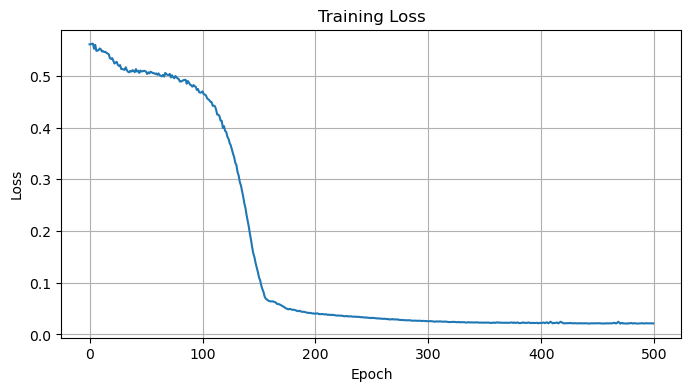

UDF range: [0.014, 1.820]
Near-surface points (udf < 0.1): 100

✅ Minimal DeepUDF training complete!


In [11]:
# Quick evaluation
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Test UDF evaluation
model.eval()
with torch.no_grad():
    test_coords = torch.randn(1, 1000, 3).to(device) * 0.5
    test_udf = model(test_coords, torch.tensor([0], device=device))
    print(f"UDF range: [{test_udf.min():.3f}, {test_udf.max():.3f}]")
    print(f"Near-surface points (udf < 0.1): {torch.sum(test_udf < 0.1).item()}")

print("\n✅ Minimal DeepUDF training complete!")

In [12]:
# Compare Original vs Reconstructed
model.eval()
with torch.no_grad():
    original_points = peptide_data[0]["points"].numpy()

    resolution = 64
    grid_range = 1.2
    x = np.linspace(-grid_range, grid_range, resolution)
    y = np.linspace(-grid_range, grid_range, resolution)
    z = np.linspace(-grid_range, grid_range, resolution)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

    grid_coords = np.stack([X.flatten(), Y.flatten(), Z.flatten()], axis=-1)
    grid_tensor = torch.tensor(grid_coords, dtype=torch.float32, device=device).unsqueeze(0)
    shape_idx_tensor = torch.tensor([0], device=device)

    batch_size = 10000
    udf_values = []
    for i in range(0, len(grid_coords), batch_size):
        batch_coords = grid_tensor[:, i:i+batch_size]
        batch_udf = model(batch_coords, shape_idx_tensor)
        udf_values.append(batch_udf.cpu().numpy())

    udf_grid = np.concatenate(udf_values, axis=1).reshape(resolution, resolution, resolution)

    surface_mask = udf_grid < 0.05
    surface_indices = np.where(surface_mask)
    reconstructed_points = np.column_stack([
        x[surface_indices[0]],
        y[surface_indices[1]],
        z[surface_indices[2]]
    ])

    fig = make_subplots(rows=1, cols=3, specs=[[{'type': 'scatter3d'}]*3], subplot_titles=['Original', 'Reconstructed', 'Overlay'])
    fig.add_trace(go.Scatter3d(x=original_points[:,0], y=original_points[:,1], z=original_points[:,2],
                              mode='markers', marker=dict(size=1, color='blue'), name='Original'), row=1, col=1)
    if len(reconstructed_points) > 0:
        fig.add_trace(go.Scatter3d(x=reconstructed_points[:,0], y=reconstructed_points[:,1], z=reconstructed_points[:,2],
                                  mode='markers', marker=dict(size=1, color='red'), name='Recon'), row=1, col=2)
        fig.add_trace(go.Scatter3d(x=original_points[:,0], y=original_points[:,1], z=original_points[:,2],
                                  mode='markers', marker=dict(size=1, color='blue', opacity=0.4), showlegend=False), row=1, col=3)
        fig.add_trace(go.Scatter3d(x=reconstructed_points[:,0], y=reconstructed_points[:,1], z=reconstructed_points[:,2],
                                  mode='markers', marker=dict(size=1, color='red', opacity=0.4), showlegend=False), row=1, col=3)
    fig.show()

    print(f"Original points: {len(original_points):,}")
    print(f"Reconstructed surface points: {len(reconstructed_points):,}")
    print(f"UDF value range: [{udf_grid.min():.3f}, {udf_grid.max():.3f}]")
    print(f"Surface points (udf < 0.05): {np.sum(udf_grid < 0.05):,} / {udf_grid.size:,}")

    if len(reconstructed_points) > 0:
        orig_center = np.mean(original_points, axis=0)
        recon_center = np.mean(reconstructed_points, axis=0)
        orig_scale = np.std(original_points)
        recon_scale = np.std(reconstructed_points)

        center_diff = np.linalg.norm(orig_center - recon_center)
        scale_diff = abs(orig_scale - recon_scale)

        print(f"Center difference: {center_diff:.4f}")
        print(f"Scale difference: {scale_diff:.4f}")

        if center_diff < 0.1 and scale_diff < 0.1:
            print("✅ Good reconstruction quality!")
        else:
            print("⚠️ Reconstruction may need improvement")
    else:
        print("❌ No surface points found - model may not have learned the shape")

Original points: 3,000
Reconstructed surface points: 2,717
UDF value range: [0.014, 1.908]
Surface points (udf < 0.05): 2,717 / 262,144
Center difference: 0.0027
Scale difference: 0.0188
✅ Good reconstruction quality!
